# Lab 4.1 — Segmentation, differentiation and fairness

*Prerequisite: labs 1.1 to 1.3 and stage 2.*

[Lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) found the best *single* price for each site. But a single price
is a compromise, and [lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb) showed why: inside this one small business
live four completely different demand curves, from a bargain hunter who
leaves for 30bp to an airside traveller who barely notices a point.

One price overcharges the sensitive and undercharges the insensitive. It
loses volume it wanted and leaves margin it could have had, simultaneously.

This notebook covers:

- what perfect differentiation would be worth (a real number);
- why you cannot have it, and what a **fence** is;
- the mix trap that makes segmented reporting lie to you;
- and the part that matters most and is taught least: **where the line is**
  between smart differentiation and treating customers badly — commercially,
  legally, and in the mirror.

The fairness material is not an appendix to the commercial material. Under
the UK's Consumer Duty, "we can charge it because they'll pay it" is not a
defensible pricing rationale, and a pricing manager who cannot argue fair
value is a liability to their employer.

---

## The three degrees of price discrimination

Economists number them, and the numbering is genuinely useful because it
tells you how much information you need.

| Degree | What it means | Example | Needs |
|---|---|---|---|
| **First** | Every customer pays their own maximum | A haggling market trader | Perfect knowledge of each person |
| **Second** | Prices vary by a *choice the customer makes* | Bulk discounts, first class, order-size tiers | Nothing — customers sort themselves |
| **Third** | Prices vary by *group membership* | Student rates, regional pricing, channel pricing | Ability to verify the group |

First degree is a fantasy (and mostly illegal in consumer markets when it is
based on personal data). Third degree is powerful but is where the fairness
and legal risk concentrates. **Second degree is where most of the practical
money is**, because the customer does the sorting for you and — crucially —
can see and understand the deal on offer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth
from toolkit import C as PALETTE

style()

quotes = load("fct_quotes")
products = load("dim_products")
customers = load("dim_customers")
transactions = load("fct_transactions")
answer_key = truth()

df = quotes.copy()
df["log_order"] = np.log(df["order_value_gbp"] / 400)
model = smf.logit("converted ~ C(segment) * quoted_margin_pp + C(segment) * comp_best_margin_pp "
                  "+ season_z + log_order + loyalty_member + C(site_id)", data=df).fit(disp=0)

# the same fast pricing engine as notebook 08
eta = np.asarray(model.predict(df, which="linear"))
observed_margin = df["quoted_margin_pp"].to_numpy()
slope = np.full(len(df), model.params["quoted_margin_pp"])
for term, coefficient in model.params.items():
    if term.endswith(":quoted_margin_pp"):
        slope[(df["segment"] == term.split("[T.")[1].split("]")[0]).to_numpy()] += coefficient
context = eta - slope * observed_margin

value = df["order_value_gbp"].to_numpy()
is_online = df["channel"].eq("online").to_numpy()
is_card = df["product_id"].eq("TRAVEL_CARD").to_numpy()
is_collect = df["fulfilment"].eq("click_collect").to_numpy()
is_delivery = df["fulfilment"].eq("delivery").to_numpy()

variable_cost = (value * df["funding_cost_bp"].to_numpy() / 10000
                 + value * np.where(is_online, 0.009, 0.002)
                 + df["product_id"].map(products.set_index("product_id")["handling_cost_gbp"]).to_numpy()
                 + 0.90 * is_collect
                 + np.where(is_delivery & ~is_card, 4.50, 0.0)
                 + value * np.where(~is_online, 0.0055, np.where(is_collect, 0.0028, 0.0)))
fixed_money = df["product_id"].map(products.set_index("product_id")["card_fee_gbp"]).to_numpy() * is_card - variable_cost

grid = np.round(np.arange(1.0, 12.01, 0.05), 2)


def curve(mask):
    s, c, v, f = slope[mask], context[mask], value[mask], fixed_money[mask]
    return np.array([(1 / (1 + np.exp(-(c + s * m))) * (v * m / 100 + f)).sum() for m in grid])


def best_price(mask):
    values = curve(mask)
    return grid[values.argmax()], values.max()


everyone = np.ones(len(df), dtype=bool)
uniform_margin, uniform_profit = best_price(everyone)
years = df["date"].dt.year.nunique()
print(f"one price for the whole business: {uniform_margin:.2f}pp -> {money(uniform_profit)} over {years} years")

one price for the whole business: 4.50pp -> £1,991,238 over 3 years


## What differentiation is worth

Now price each segment at its own optimum and add up. This is the
theoretical ceiling — what you would earn if you could see, at the counter,
which of the four kinds of customer had just walked in.

In [2]:
rows = []
for segment in sorted(df["segment"].unique()):
    mask = (df["segment"] == segment).to_numpy()
    margin, profit = best_price(mask)
    at_uniform = curve(mask)[grid == uniform_margin][0]
    rows.append({"segment": segment,
                 "best price": margin,
                 "truth": answer_key["optimal_uniform_margin_pp"]["by_segment"][segment],
                 "contribution at its own price": profit,
                 "contribution at the single price": at_uniform,
                 "gain": profit - at_uniform})

seg = pd.DataFrame(rows)
total_differentiated = seg["contribution at its own price"].sum()
print(seg.round(2).to_string(index=False))
print(f"\nsingle price      : {money(uniform_profit)}")
print(f"perfect targeting : {money(total_differentiated)}   "
      f"(+{total_differentiated / uniform_profit - 1:.1%})")

       segment  best price  truth  contribution at its own price  contribution at the single price      gain
bargain_hunter        3.45   3.40                      195288.26                         163610.10  31678.16
frequent_flyer        4.20   4.15                      743608.17                         737002.38   6605.80
holiday_family        4.55   4.60                      762757.01                         762594.87    162.14
   last_minute        8.65  10.00                      515492.10                         328030.23 187461.86

single price      : £1,991,238
perfect targeting : £2,217,146   (+11.3%)


**Around a tenth more contribution from the same customers, the same costs
and the same demand** — just by charging four prices instead of one. Against
a group operating profit measured in the low hundreds of thousands, that is
transformational.

Look at where it comes from. The bargain hunter should pay about **3.4pp**
and the last-minute traveller **more than double that** for an identical
product bought minutes apart. The model is not being cynical; it is
reporting that these two people have very different alternatives.

And that is exactly where the discomfort starts. Hold it — we will come back
to it with tools rather than vibes.

## The catch: you cannot see segments

`segment` is a column in our data because we built the world. In reality
nobody walks in wearing a label. You have three options, in ascending order
of both practicality and risk:

1. **Infer it from data** (a model that predicts price sensitivity from
   observed features). Powerful, and the fastest route to a regulatory
   problem if the features are proxies for protected characteristics.
2. **Ask** (a loyalty scheme, a declared purpose). Honest, low coverage.
3. **Build a fence** — set prices by something the customer *chooses*, so
   they sort themselves.

### Fences

A fence is a rule that makes the cheaper deal available to everyone but
attractive only to the price-sensitive. Airline advance purchase, bulk
discounts, off-peak fares, "online only" pricing, coupon codes — all fences.

**The three tests of a good fence:**

| Test | Question | Fails when |
|---|---|---|
| **Self-selection** | Can any customer choose the cheaper option? | You price by who they *are* |
| **Correlation** | Do the customers who choose it actually have higher sensitivity? | The fence is decorative |
| **Defensibility** | Can you explain it in one sentence to a customer or a regulator? | You cannot say it out loud |

Let's build one from variables Meridian can actually observe at the moment
of quoting: **which channel the customer chose**, and **how much they are
buying**.

In [3]:
size_band = pd.cut(df["order_value_gbp"], [0, 250, 600, 10000],
                   labels=["under £250", "£250-600", "over £600"])
fence_key = df["channel"].astype(str) + " | " + size_band.astype(str)

fence_total, fence_rows = 0.0, []
for key in sorted(fence_key.unique()):
    mask = (fence_key == key).to_numpy()
    margin, profit = best_price(mask)
    fence_total += profit
    fence_rows.append({"cell": key, "quotes": int(mask.sum()), "price": margin})

fence = pd.DataFrame(fence_rows)
print(fence.pivot_table(index=fence["cell"].str.split(" | ", regex=False).str[0],
                        columns=fence["cell"].str.split(" | ", regex=False).str[1],
                        values="price").to_string())

print(f"\nsingle price                : {money(uniform_profit)}")
print(f"observable fence            : {money(fence_total)}   (+{fence_total / uniform_profit - 1:.1%})")
print(f"perfect segment targeting   : {money(total_differentiated)}   "
      f"(+{total_differentiated / uniform_profit - 1:.1%})")
print(f"\nthe fence captures {(fence_total - uniform_profit) / (total_differentiated - uniform_profit):.0%} "
      "of the theoretical prize using only what we can actually observe")

cell     over £600  under £250  £250-600
cell                                    
airport       5.35        8.95      6.05
branch        4.00        4.35      4.05
online        4.25        5.65      4.50

single price                : £1,991,238
observable fence            : £2,097,533   (+5.3%)
perfect segment targeting   : £2,217,146   (+11.3%)

the fence captures 47% of the theoretical prize using only what we can actually observe


Roughly half of the theoretical prize, using nothing but the channel the
customer picked and the size of their order. That ratio — **a practical
fence captures a third to a half of perfect targeting** — is a good default
expectation to carry into a business case, and it protects you from
promising the full number.

One cell in that table is already a governance problem: small orders at the
airport kiosks price out well beyond the board's 7.5pp cap. The optimiser does not know the cap exists. That is not a bug to hide —
it is the moment the fairness conversation below has to happen, and it is
better to have it while the number is still on a screen rather than a rate
board.

Note also what the fence discovered on its own: large orders should be
priced *keener* than small ones (they shop harder), and the airport should
charge more than the website. Both are commercially standard, both are explainable
to a customer in one sentence, and neither requires knowing anything
personal about anybody.

## The mix trap: when segmented reporting lies

Before the fairness section, a hazard that lives entirely inside segmented
analysis, and which will eventually cost you an argument in a meeting.

**A worked example with small numbers.** Two branches, this year vs last:

| | Last year | | This year | |
|---|---|---|---|---|
| | orders | margin | orders | margin |
| Airport | 100 | 6.0pp | 100 | 6.2pp |
| High street | 100 | 3.0pp | 300 | 3.2pp |
| **Total** | **200** | **4.50pp** | **400** | **3.95pp** |

Every branch raised its price. The company's average price **fell by 55bp**.
Nothing is wrong with the arithmetic: the low-price branch grew, so it
carries more weight.

This is **Simpson's paradox**, and in pricing it shows up constantly —
because growth is rarely uniform across a portfolio. Two consequences:

1. **Never judge a rate move from a blended average.** Decompose first
   ([lab 1.1](../01_set_the_rate/lab_01_price_cost_and_profit.ipynb)'s price–volume–mix bridge exists for exactly this).
2. **The reverse also happens**: a genuine across-the-board price cut can be
   hidden by mix shifting towards expensive segments, so nobody notices the
   leak for a year.

We met the same phenomenon in [lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb) in its most dangerous form: pooled
across sites, conversion *rose* with price; within any single site it fell.
Same data, opposite conclusions, and only one of them is about customer
behaviour.

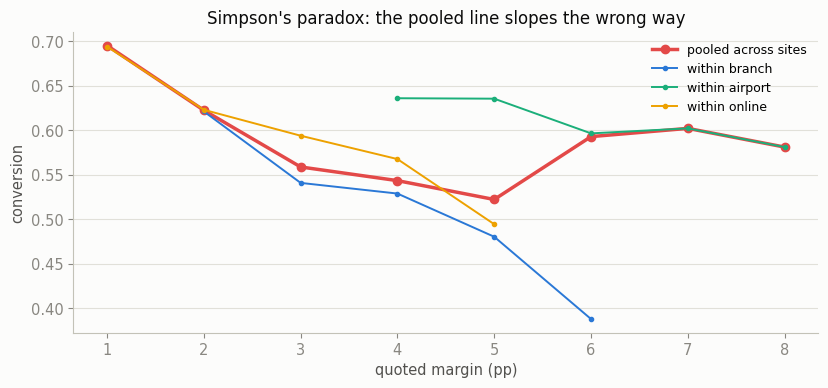

In [4]:
pooled = (df.assign(m=df["quoted_margin_pp"].round(0))
          .groupby("m")["converted"].agg(["mean", "count"]))
pooled = pooled[pooled["count"] > 2000]

fig, ax = plt.subplots(figsize=(8.4, 4.0))
ax.plot(pooled.index, pooled["mean"], color=PALETTE[5], lw=2.5, marker="o", label="pooled across sites")
for i, site in enumerate(["branch", "airport", "online"]):
    sub = df[df["channel"] == site]
    g = sub.assign(m=sub["quoted_margin_pp"].round(0)).groupby("m")["converted"].agg(["mean", "count"])
    g = g[g["count"] > 500]
    ax.plot(g.index, g["mean"], color=PALETTE[i], lw=1.4, marker=".", label=f"within {site}")

ax.set_xlabel("quoted margin (pp)")
ax.set_ylabel("conversion")
ax.set_title("Simpson's paradox: the pooled line slopes the wrong way")
ax.legend(fontsize=9)
tidy(ax)
plt.tight_layout()
plt.show()

## Fairness: the part that is not optional

Our model says the last-minute traveller should pay 9.50pp and the bargain
hunter 3.35pp. Before implementing anything like that, work through four
questions in order. They are the questions a regulator, a journalist and a
thoughtful colleague will ask, and they have decent answers.

### 1. What is the *basis* of the difference?

| Basis | Example | Standing |
|---|---|---|
| **Cost to serve** | Online costs 2.01pp to serve, a branch 0.69pp | Strongest. Easy to defend, easy to explain |
| **A choice the customer made** | Buying at the airport 40 minutes before a flight; ordering £3,000 | Good, if the alternative was genuinely available |
| **Value delivered** | Guaranteed availability, immediate collection | Reasonable, if the value is real |
| **Group membership** | Students, loyalty tiers | Depends entirely on the group and the reason |
| **Inability to shop around** | No phone signal airside; not digitally confident; in a hurry | **Weak, and getting weaker in law** |
| **Protected characteristics** | Age, race, sex, disability — or proxies for them | Prohibited |

Our airport premium sits between rows two and five, and *which one it is*
depends on facts we can check: is there a genuine alternative? Are the
prices displayed clearly before commitment? Is the customer able to compare?

### 2. Does the outcome concentrate on people who cannot protect themselves?

This is the empirical question, and it is one you can answer with data in an
afternoon. It is also the one most teams skip, because nobody asks — and
because the answer is often uncomfortable.

Our business has a channel price gap and customers who sort themselves into
channels partly by age and digital confidence. So before proposing *any*
differentiated pricing, look at who pays what today.

In [5]:
paid = transactions.merge(customers[["customer_id", "age_band", "digital_engaged", "region_id"]],
                          on="customer_id", how="left", suffixes=("", "_home"))


def weighted_margin(g):
    return (g["order_value_gbp"] * g["margin_pp"]).sum() / g["order_value_gbp"].sum()


audit = paid.groupby("age_band").apply(
    lambda g: pd.Series({"realised margin (pp)": weighted_margin(g),
                         "orders": len(g),
                         "share buying online": (g["channel"] == "online").mean(),
                         "contribution per order": g["contribution_gbp"].mean()}), include_groups=False)
print(audit.round(3).to_string())

digital = paid.groupby("digital_engaged").apply(
    lambda g: pd.Series({"realised margin (pp)": weighted_margin(g),
                         "share buying online": (g["channel"] == "online").mean()}), include_groups=False)
print("\n", digital.round(3).to_string())

          realised margin (pp)   orders  share buying online  contribution per order
age_band                                                                            
18-29                    3.428  39176.0                0.412                   9.922
30-44                    3.438  60411.0                0.410                   9.885
45-59                    3.499  49088.0                0.329                  10.533
60+                      3.551  28981.0                0.280                  10.810

                  realised margin (pp)  share buying online
digital_engaged                                           
0                               3.574                0.245
1                               3.428                0.417


**The audit finds a gap, and it runs the way you would fear.** Older
customers and the digitally unengaged pay a higher realised margin, and the
mechanism is visible in the next column: they buy in branches, and branches
charge more than the website.

Notice what did **not** happen. Nobody decided to charge older customers
more. There is no age term in the rate card, no proxy variable in a model,
no discriminatory intent anywhere in the business. The gap is the mechanical
consequence of two entirely defensible decisions — *branches cost more to
serve, so they charge more* and *customers choose their own channel* —
meeting a fact about the world: **not everyone can choose equally**.

That is the anatomy of almost every "loyalty penalty" scandal of the last
decade, and it is why the FCA's Consumer Duty asks about *outcomes by group*
rather than about intent. Three things follow for a pricing manager:

1. **Measure it before someone else does.** This audit is four lines of
   pandas. Not running it is a choice.
2. **Ask whether the difference is justified by cost, and by how much.** If
   branch cost-to-serve genuinely exceeds online by 0.6pp and the price gap
   is 0.6pp, you have a defence. If the gap is 1.5pp, you have a problem —
   and the arithmetic is the same arithmetic either way.
3. **Check the tails, not just the means.** What share of each group pays in
   the top decile of margins? An average that looks tolerable can hide a
   group of customers being badly served.

### 3. Would you be comfortable publishing the rule?

The most useful ethical test in commercial pricing is not a framework, it is
a sentence:

> **Write the pricing rule as one plain sentence, and imagine it printed in
> a newspaper next to a photograph of the customer it affects most.**

- *"Customers who order more than £600 get a keener rate."* Fine. Print it.
- *"Customers at the airport pay more because we cost more to operate there
  and they value immediate availability."* Fine, if true.
- *"Customers who cannot compare prices pay more."* Not fine. And notice
  that this is precisely what an unconstrained optimiser will discover, because
  inability to compare *is* low elasticity.

That last point is the heart of it. **Elasticity does not distinguish
between a customer who is relaxed about price and a customer who is
trapped.** The model sees the same low number. Only you can tell the
difference, and the fact that the maths cannot is the reason the judgement
cannot be delegated to the maths.

### 4. What does the constraint cost, and is it worth it?

Do not argue about the cap in the abstract. Price it.

In [6]:
POLICY_CAP = 7.50      # the board's maximum margin on any product, any site

capped_total = 0.0
for segment in sorted(df["segment"].unique()):
    mask = (df["segment"] == segment).to_numpy()
    values = curve(mask)
    capped_total += values[grid <= POLICY_CAP].max()

print(f"perfect targeting, uncapped     : {money(total_differentiated)}  "
      f"(+{total_differentiated / uniform_profit - 1:.1%} vs one price)")
print(f"perfect targeting, capped at {POLICY_CAP}pp: {money(capped_total)}  "
      f"(+{capped_total / uniform_profit - 1:.1%})")
print(f"\ncost of the fairness cap        : {money(total_differentiated - capped_total)} over {years} years")
print(f"                                = {(total_differentiated - capped_total) / (total_differentiated - uniform_profit):.0%} "
      "of the differentiation prize, and it falls entirely on the last-minute segment")

perfect targeting, uncapped     : £2,217,146  (+11.3% vs one price)
perfect targeting, capped at 7.5pp: £2,202,857  (+10.6%)

cost of the fairness cap        : £14,289 over 3 years
                                = 6% of the differentiation prize, and it falls entirely on the last-minute segment


That is the sentence for the committee:

> *"The 7.5pp cap costs us a low single-digit percentage of what
> differentiated pricing is worth. It applies to one segment: travellers
> buying airside with no practical alternative. I recommend we keep the cap,
> and here is the reasoning."*

And notice how *cheap* the ethical constraint turned out to be. That is the
usual finding, and it is worth knowing before the argument starts: the
profit at stake in the uncomfortable corner of a pricing policy is almost
always small relative to the reputational and regulatory exposure. Teams
that never do this arithmetic end up defending a position worth far less
than they imagined.

You have not refused to do the analysis, and you have not hidden behind it.
You have priced the ethical constraint and made it a decision the business
takes deliberately. That is what senior pricing judgement looks like in
practice, and it is far more persuasive than either "the model says 9.5pp"
or "that feels wrong".

## The rules that actually bind (UK)

| Regime | What it requires | Pricing consequence |
|---|---|---|
| **FCA Consumer Duty** | Products must offer **fair value**: price reasonable relative to benefits, assessed by group | You must be able to evidence value, per customer group — not just in aggregate |
| **Vulnerable customer guidance** | Identify and avoid exploiting vulnerability | "Low elasticity because they cannot shop" is a red flag, not an opportunity |
| **Price walking ban** (general insurance) | Renewal price cannot exceed the equivalent new-business price | Kills "raise the price of the loyal" as a strategy in that market — and signals the direction of travel elsewhere |
| **Equality Act** | No discrimination on protected characteristics | Includes *proxies*: postcode, name, device can all encode ethnicity or age |
| **UK GDPR, Art. 22** | Rights around solely automated decisions | Personalised pricing engines need governance, explanation, human review |
| **Competition Act** | No price fixing or signalling | Do not discuss future pricing with rivals. Careful with public "we will match" statements — they can be read as signalling ([lab 1.4](../01_set_the_rate/lab_04_competition_and_dynamics.ipynb)) |

The direction of travel is consistent: **differentiate on cost and on
choices; do not differentiate on vulnerability, on ignorance, or on
anything that stands in for a protected characteristic.**

A practical governance shape that satisfies most of this:

1. Written pricing principles, approved once, that name the permitted bases
   for differentiation.
2. A fair-value assessment per customer group, refreshed annually with the
   data above.
3. Guardrails in the pricing system: caps, floors, maximum move sizes, and a
   list of features the model is *not allowed to use*.
4. A human review step for any price outside the guardrails.
5. Monitoring that reports outcomes by group, not just profit.

## Practice

1. Your model finds that customers who load the mobile app between 11pm and
   2am convert regardless of price, and recommends charging them 2pp more.
   Do you implement it?
2. A colleague proposes: "everyone who signs up to our newsletter gets 20bp
   off." Evaluate it as a fence.
3. Segmented pricing raises contribution 13%. The board asks why you are
   recommending the version that only delivers 4%.

<details>
<summary>Answers</summary>

1. No — not as stated, and the reason is diagnostic rather than squeamish.
   "Converts regardless of price at 1am" is a *correlate* of something, and
   you do not know what: shift workers, insomniacs, people in other time
   zones, or customers in distress buying currency for an emergency. Before
   any of it, ask what the mechanism is. If it turns out to be "no
   alternative is open", you are pricing inability to shop, which fails the
   newspaper test and probably the Consumer Duty one. If it turns out to be
   "these are business travellers expensing it", you have a defensible
   *purpose-based* fence — and you should implement it as an explicit,
   explainable rule rather than as a time-of-day coefficient buried in a
   model.

2. As a fence it is weak on **correlation** — newsletter signup does not
   especially select price-sensitive customers; it selects engaged ones,
   who may be your best customers already. So you would give margin away to
   people who would have paid full price. It scores well on
   self-selection and defensibility. Better fences for this business:
   order-size thresholds, advance-order windows, or click-and-collect —
   each of which requires the customer to give something up in exchange for
   the discount.

3. Because 13% assumes you can identify each customer's segment at the
   moment of quoting, and you cannot. The 4% version uses only what is
   observable and self-selected, which makes it implementable this quarter,
   explainable to a customer, and defensible to the FCA. Then say what
   would move it up: better identification through the loyalty scheme
   (with consent), an advance-order fence, and a test of a third size band.
   Recommending the achievable number and naming the path to the rest is
   what makes the next recommendation get funded.

</details>

---

**Next:** `10_competition_and_dynamics.ipynb` — you do not price alone, and
the market moves back.